In [2]:
import scipy as sp
import numpy as np
import os
import matplotlib.pyplot as plt

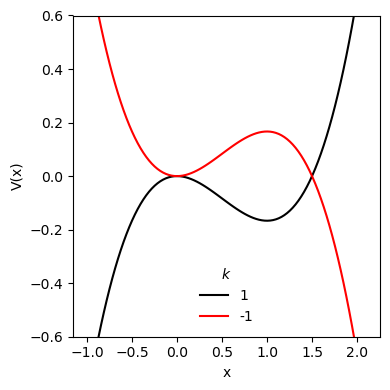

In [48]:
V = lambda x, k: -k*x*x*(1/2 - x/3)

x = np.linspace(-1, 2.1, 100)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot(x, V(x, 1), '-', color = 'k', label  = '1')
ax.plot(x, V(x, -1), '-', color = 'r', label  = '-1')
ax.set_xlabel("x")
ax.set_ylabel("V(x)")
ax.set_ylim([-0.6, 0.6])
plt.tight_layout()
ax.legend(frameon = False, title="$k$")
plt.savefig("4.pdf")
plt.show()


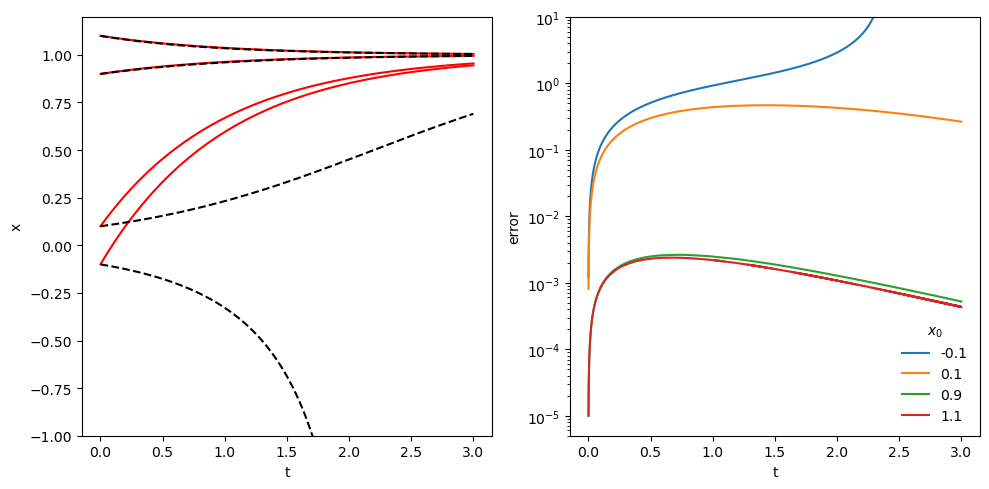

In [40]:
x0s = [-0.1, 0.1, 0.9, 1.1]
x = lambda t, x0 : 1 - (1 - x0)*np.exp(-t)

fig, ax = plt.subplots(1,2, figsize=(10,5))

for i in range(4):
    data = np.loadtxt(f"lab1_1d_{i}.dat").T
    ax[0].plot(data[0], x(data[0], x0s[i]), '-', label=f"{-1 + i*0.2}", color = 'r')
    ax[0].plot(data[0], data[1], '--', label=f"{-1 + i*0.2}", color = 'k')
    ax[1].semilogy(data[0], np.abs(x(data[0], x0s[i]) - data[1]), '-', label = f"{x0s[i]}")
    
ax[0].set_ylim([-1, 1.2])
ax[1].set_ylim([0.5e-5, 10])
ax[0].set_xlabel("t")
ax[0].set_ylabel("x")
ax[1].set_xlabel("t")
ax[1].set_ylabel("error")
ax[1].legend(frameon = False, title="$x_0$")
plt.tight_layout()
plt.savefig("3.pdf")
plt.show()

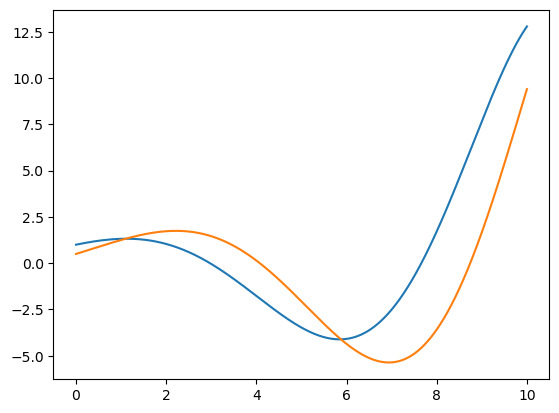

In [ ]:
data = np.loadtxt(f"wyniki/lab1.dat").T

plt.plot(data[0], data[1], label="x(t)")
plt.plot(data[0], data[2], label="y(t)")
plt.show()

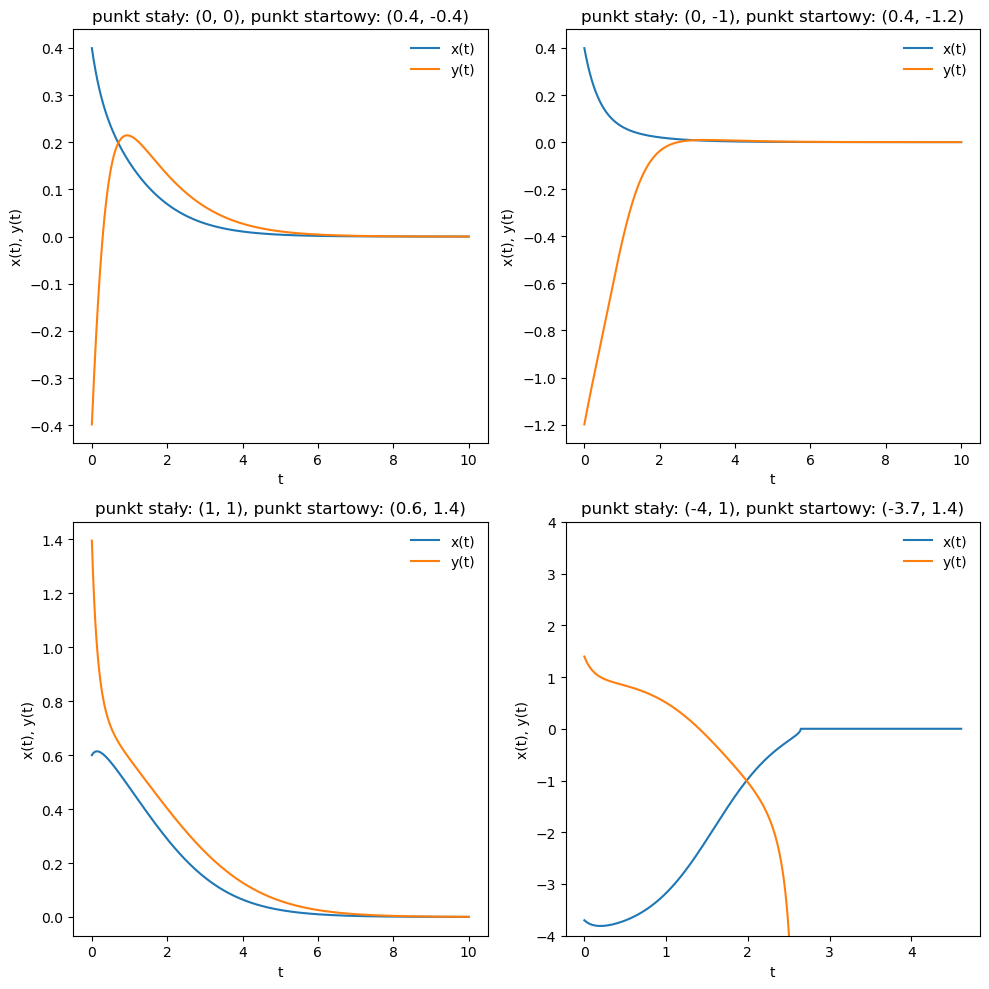

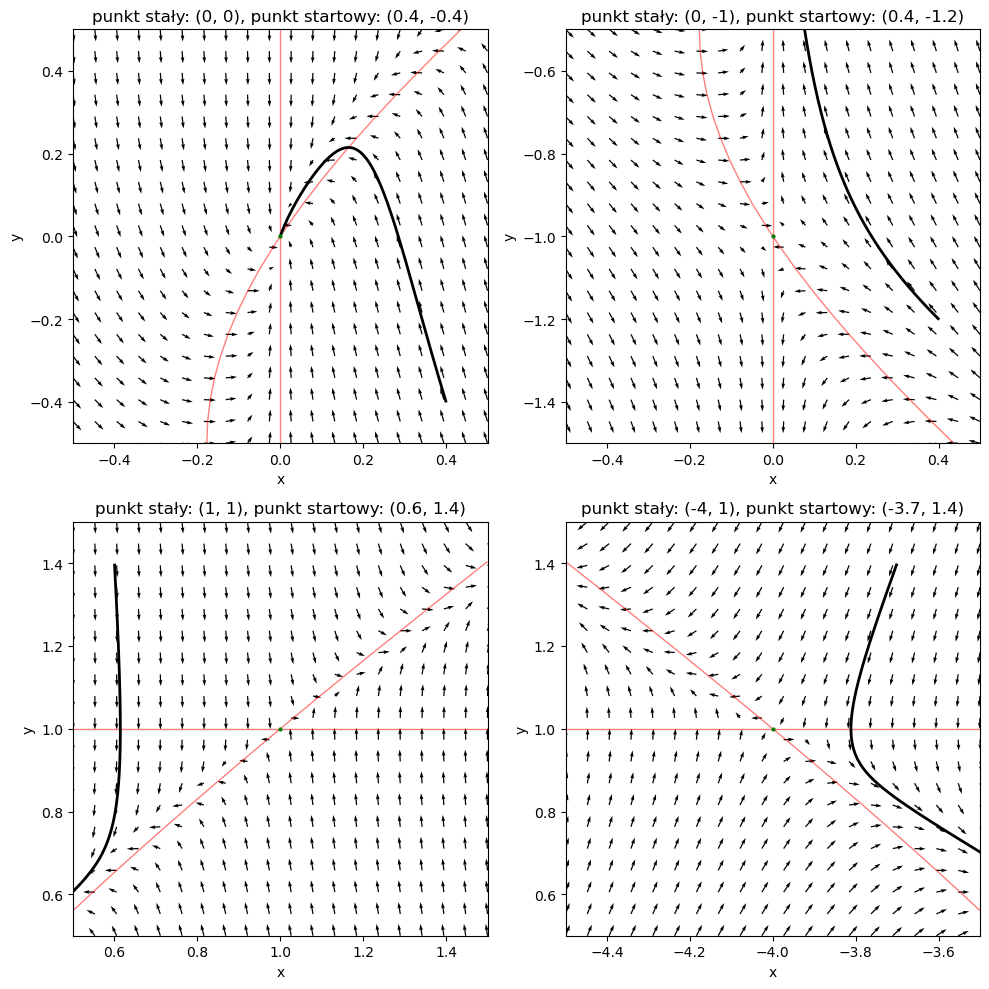

In [112]:
# system of equations:
# dx/dt = alpha*x - beta*x*y
# dy/dt = - gamma*y + delta*x*y

punkty = [(0,0), (0,-1), (1,1), (-4, 1)]
punkty_startowe = [(0.4, -0.4), (0.4, -1.2), (0.6, 1.4), (-3.7, 1.4)]
fig, ax2 = plt.subplots(2,2, figsize=(10, 10))
data = []

ax2 = ax2.flatten()
for i, punkt in enumerate(punkty):
    data.append(np.loadtxt(f"wyniki/lab_{i}.dat").T)

    ax2[i].plot(data[-1][0], data[-1][1], label="x(t)")
    ax2[i].plot(data[-1][0], data[-1][2], label="y(t)")
    ax2[i].set_xlabel("t")
    ax2[i].set_ylabel("x(t), y(t)")
    ax2[i].set_title(f"punkt stały: {punkt}, punkt startowy: {punkty_startowe[i]}")
    ax2[i].legend(frameon=False)
ax2[3].set_ylim([-4, 4])
plt.tight_layout()
plt.savefig("1_xy.pdf")
plt.show()  


def alpha(x,y):

    return x*(y - 1)

def beta(x,y):
    return 3*x - 2*y + x*x - 2*y*y

fig1, ax1 = plt.subplots(2, 2, figsize=(10, 10))
ax1 = ax1.flatten()
for i, punkt in enumerate(punkty):
    
    x = np.linspace(punkt[0] - 0.5, punkt[0] + 0.5, 20)
    y = np.linspace(punkt[1] - 0.5, punkt[1] + 0.5, 20)
    X, Y = np.meshgrid(x, y)

    Alpha = alpha(X, Y)
    Beta = beta(X, Y)
    ax1[i].contour(X, Y, Alpha, levels=0, colors='r', linewidths=1, alpha=0.5)
    ax1[i].contour(X, Y, Beta, levels=0, colors='r', linewidths=1, alpha=0.5)
    ax1[i].plot(data[i][1], data[i][2], '-', color='k', linewidth=2)
    
    U = X * (Y - 1)
    V = 3 * X - 2 * Y + X * X - 2 * Y * Y

    U /= np.sqrt(U * U + V * V) + 1e-6
    V /= np.sqrt(U * U + V * V) + 1e-6

    ax1[i].set_xlim([punkt[0] - 0.5, punkt[0] + 0.5])
    ax1[i].set_ylim([punkt[1] - 0.5, punkt[1] + 0.5])
    Q = ax1[i].quiver(X, Y, U, V)
    ax1[i].plot(punkt[0], punkt[1], 'o', color='g', markersize=2)
    ax1[i].set_title(f"punkt stały: {punkt}, punkt startowy: {punkty_startowe[i]}")
    ax1[i].set_xlabel('x')
    ax1[i].set_ylabel('y')


plt.tight_layout()
plt.savefig("2_quiver_xy.pdf")
plt.show()